In [44]:
import numpy as np
import scipy as sp
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap , Normalize
from matplotlib.patches import Circle 
import os
import imageio
import glob

# Population model

1.6666666666666667


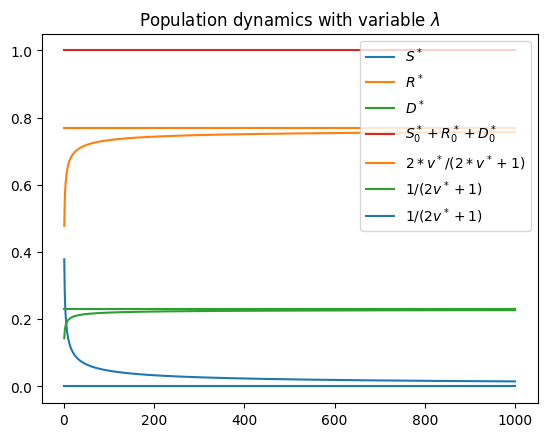

In [63]:
"""The steady state solution of the population model is given by 
S^*_0 = (-1 + sqrt{1+4 lam^* (2nu^*+1)}) / ( 2 lam^* (2nu^*+1))
R^*_0 = 2 lam^* nu^* S^{2*}_0
D^*_0 = lam^* S^{2*}_0
"""

lam = 0.5
nu = 5
t0 = 3

n=400
T=60


# Dimentionless:
nu = nu / t0
print(nu)
S = lambda x : ( -1 + np.sqrt(1+4*x*(2*nu+1)) ) / ( 2*x*(2*nu+1) )
R = lambda x : 2 * x * nu * (S(x)**2)
D = lambda x : x * (S(x)**2)

h = 1000
xp = np.linspace(1,h,h)

plt.plot(xp ,S(xp), label = '$S^*$')
plt.plot(xp ,R(xp), label = '$R^*$')
plt.plot(xp ,D(xp), label = '$D^*$')
plt.plot(xp ,S(xp) + R(xp) + D(xp), label="$S^*_0 + R^*_0 + D^*_0$" )
plt.plot(xp, 2*nu/(2*nu+1)+xp*0, label = "$2*v^*/(2*v^*+1)$", color = "#ff7f0e")
plt.plot(xp, 1/(2*nu+1)+xp*0 , label = "$1/(2v^*+1)$", color="#2ca02c")
plt.plot(xp, xp*0 , label = "$1/(2v^*+1)$", color="#1f77b4")
plt.legend()
plt.title(f'Population dynamics with variable $\lambda$')
plt.show()

# Defining the Dancers class

In [46]:
class Dancers:
    def __init__(self, n , grid , ratio , mu , nu , eta ,sigma, V , Delta , OffGrid = None ):
        """ Initiating the dance floor
        First we initiate the fixed properties given by the input parameters and then we 
        initiate properties that may change at some time step: position and rest state.

        In particular, we have a Offgrid parameter that decides wether the implementation is 
        done on a lattice, in the case OffGrid has None value, or if it is done off lattice in 
        which case Offgrid takes the role ofmatch radius. 
        Therefore, in the lattice model a match is made if two suitable dancers are on the exact 
        same grid position while in the offlattice model a match is made if the two dancers are 
        within 'OffGrid' distance from eachother.

        Skill levels are assigned according to a Gaussian distribution with mean mu and standard 
        deviation 1. Initial positions are chosen randomly from coordinates on the edges of the grid.

        Furthermore, dancers can have 2 different states: resting and searching.
        When resting, the dancers are removed from the dance floor and do not interact with other
        dancers. 
        This state is represented by a negative rest value that follows a Poisson distribution 
        with mean nu.
        At each time step, the dancers regain some energy: their rest value increases by 1.
        Once a song ends, dancers that are rested (represented by a 0 rest value) will join 
        the dance floor once again and enter the searching state. 
        While they are searching, the dancers will keep moving until they find a 
        match and dance. At the end of the song they will then enter the resting state.
        """
        #  ======= Fixed Properties =======
        self.Delta = Delta   # Time step
        self.n = n           # Numb of dancers
        self.grid = grid     # Lenght of square grid

        # Assign roles to dancers according to ratio
        self.role = - np.ones(self.n , dtype = int ) 
        self.ratio = ratio
        n_f = int( self.n / ( ratio + 1) ) 
        self.role[:n_f]*= -1
        self.rng = np.random.default_rng()

        # Assign skill levels    
        self.mu = mu         
        self.skill = np.clip( self.rng.normal(mu, 1 , self.n) , 0 , None )

        self.nu = nu / self.Delta       # Resting rate after dancing
        self.eta = eta     # Distance bias in partner search
        self.sigma = sigma  # Skill bias in partner search

        self.OffGrid = OffGrid    # On lattice/ Off lattice switch, also used as match radius for off lattice

        self.V = V * self.Delta   # Speed parameter
        #  ======= Mutable Properties =======

        # Generate the edge coordinates of the grid for the OffGrid and OnGrid case
        if OffGrid is not None:  
            axis1 = self.rng.random(self.grid + 1) * (self.grid)
            axis2 = np.zeros(self.grid + 1)
            axis3 = (self.grid) * np.ones(self.grid +1)
            
            edges1 = np.column_stack((axis1.ravel(), axis2.ravel()))
            edges2 = np.column_stack((axis1.ravel(), axis3.ravel()))
            edges3 = np.column_stack((axis2.ravel(), axis1.ravel()))
            edges4 = np.column_stack((axis3.ravel(), axis1.ravel()))
            
            Edges = np.concatenate(( edges1, edges2, edges3, edges4 ))
            self.Edges = np.unique( Edges , axis = 1 )

        else: 
            axis1 = np.arange( self.grid + 1)
            axis2 = np.zeros( self.grid + 1)
            axis3 = (self.grid) * np.ones(self.grid + 1)
            
            edges1 = np.column_stack((axis1.ravel(), axis2.ravel()))
            edges2 = np.column_stack((axis1.ravel(), axis3.ravel()))
            edges3 = np.column_stack((axis2.ravel(), axis1.ravel()))
            edges4 = np.column_stack((axis3.ravel(), axis1.ravel()))
            
            Edges = np.concatenate(( edges1, edges2, edges3, edges4 ))
            self.Edges = np.unique( Edges , axis = 1 )

        self.position = self.rng.choice(self.Edges, self.n, replace=True)   # Assign initial positions of the dancers  

        self.rest = np.zeros(self.n)  # Assign initial rest states

        self.S = self.n      # Searching population
        self.R = 0           # Resting population
        self.lam = 0         # Matches over time




    def Grid(self , t , Showplots = None , Saveframes = None):
        """Function to visualize the movement of the dancers at each time step
        We plot the dancers on a 2x2 grid. We mark the followers '1' as circles and leaders '-1' as three pointed stars.
        We represent the skill of each dancer by the color of their marker. A colorbar is provided with each plot.  

        The parameter t is used for the title of the plot. If Showplots is given a value, the the plot will be shown on 
        the terminal. Otherwise if Saveframes is given a value, then the frames are save on a local file.        
        """
        # Define grid
        plt.figure(figsize=(6.08, 6.08))
        plt.grid(True , alpha =0.75)
        plt.xlim(-1, self.grid +1)
        plt.ylim(-1, self.grid+1 )
        plt.gca().set_aspect('equal')

        role_markers = {1: '.', -1: '1'}  # Assign markers 

        # Create the colorbar with fixed ticks
        maxskill = int(np.ceil(np.max(self.skill)))
        minskill = int(np.floor(np.min(self.skill)))
        cmap_base = plt.get_cmap('nipy_spectral', maxskill )
        cmap = ListedColormap([cmap_base(i) for i in range( minskill -1 , maxskill ) ])
        norm = Normalize( vmin= minskill - 0.5 , vmax=maxskill + 0.5)

        # Plot the positions for each role with the assigned markers and colors
        for r in [-1 , 1]:
            idx = np.where(self.role == r)[0]
            scatter = plt.scatter(
                self.position[idx, 0], self.position[idx, 1],
                marker=role_markers[r],
                c=self.skill[idx],
                cmap=cmap,
                norm=norm,
                s=1000/self.grid,
                label=f'Role: {r}'
            )

        # Place the colorbar
        cbar = plt.colorbar(scatter, ticks=np.arange( minskill -1, maxskill + 1))
        cbar.set_label('Skill Level')

        plt.legend(loc='upper right' , fontsize = 'xx-small' , markerscale = 1)

        plt.title(f"Grid at time t={t}")

        # Plott the borders of the dance floor
        plt.plot(
                [-0.5, -0.5, self.grid + 0.5, self.grid + 0.5, -0.5],  # x-coords
                [-0.5, self.grid + 0.5, self.grid + 0.5, -0.5, -0.5],  # y-coords
                color='black', linewidth=2)
        
        # # Add a circle in the center of the grid to represent the area of repulsion
        # center = (self.grid) / 2
        # radius = self.grid * 0.3
        # circle = Circle((center, center), radius,fill=False, alpha=0.3, zorder=1)
        # plt.gca().add_patch(circle)
        
        # Save or show the plots
        if Saveframes is not None: 
            # Create directory if needed
            os.makedirs(f'Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}', exist_ok=True)
            filename = f'Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/frame_{t:06.2f}.png'
            plt.savefig(filename)
        if Showplots is not None:
            plt.show(scatter)
        plt.close()





    def Movement(self , r): 
        """ Movement function 
        At every time step, the dancers move according to the the respective criteria described 
        in the report. We only consider dancers that are not resting, here referred to as 'valid dancers'.

        We compute matrix A with 

            A_{ij}= ( \frac{1-sign(r_i r_j)}{2} ) e^{- eta  ||x_i - x_j|| } e^{-sigma |s_i - s_j| }

        with r_i , x_i and s_i being the role, the position and the skill level of dancer i respectively.

        For the Offgrid model, we compute the force vector to determine the motion of the dancers. The new
        position is determined by 

            x_i(t+Dt) = x_i(t) + DtF_i(t)

        For the Ongrid model, we divide the various directions into the 4 quadrants 'up','down','left' and 'right'
        centered at each dancer i. 

                                   \\ up  //
                                    \\   //
                                     \\ //
                                left   i   right
                                     // \\
                                    //   \\
                                   // down\\

                                   
        We compute the probability of moving in each of the 4 directions by summing the probabilities within each section
        We then move the dancers by picking a grid direction based on the probabilities above.

        On the boundary we enforce solid wall boundaries. If a dancer would move across a wall, the movement is blocked and 
        dancer does not move.

        To avoid dancers skipping over each other, we split the movement of the dancers. Only dancers with role r given in 
        the input will move. 
        """

        valid_mask = ~np.isnan(self.position).any(axis=1)  # Only move non resting dancers

        valid_indices = np.where(valid_mask)[0] # Get indices of valid to place the new positions in the full array later

        # Extract properties of valid dancers
        clean_position = self.position[valid_mask]
        clean_role     = self.role[valid_mask]  
        clean_skill    = self.skill[valid_mask]

        # Compute A
        role_match = ( 1-np.sign(  np.outer(clean_role , clean_role ))   ) * 0.5   # Role bias

        if self.OffGrid is not None: dist= np.linalg.norm( clean_position[:, np.newaxis, :] - clean_position[np.newaxis, :, :], axis=2)  # Distance bias
        else: dist= np.linalg.norm( clean_position[:, np.newaxis, :] - clean_position[np.newaxis, :, :], ord = 1 , axis=2)  # Distance bias
        dist_match = np.exp(- self.eta * dist) - np.eye(len(dist))

        skilly = np.abs(clean_skill[:, None] - clean_skill[None, :])  # Skill bias
        skill_match= np.exp(- self.sigma * skilly ) - np.eye(len(skilly)) 

        A = role_match * dist_match * skill_match  

        delta = clean_position[np.newaxis, :, :] - clean_position[:, np.newaxis, :]  

        # For the Offgrid model, compute the force vector F
        if self.OffGrid is not None:
            dist = np.linalg.norm( delta , axis = 2 , keepdims=True )
            dist =  np.where(dist == 0 , 1 , dist )
            X  = delta / dist
            F = self.V * np.einsum('ij, ijk -> ik', A, X)
            clean_position += F

        # For the Ongrid model, sum the various directions into the 4 quadrants 'up','down','left' and 'right'
        else:
            dx = delta[:,:,0]
            dy = delta[:,:,1]

            # Split the grid into 4 quadrants
            Up_mask    = (dy >=  dx) & (dy >= -dx)
            Down_mask  = (dy <=  dx) & (dy <= -dx)
            Left_mask  = (dx <  dy) & (dx < -dy)
            Right_mask = (dx >  dy) & (dx > -dy)

            # Sum the probabilities
            Up_prob    = np.sum(A * Up_mask    , axis = 1)
            Down_prob  = np.sum(A * Down_mask  , axis = 1)
            Left_prob  = np.sum(A * Left_mask  , axis = 1)
            Right_prob = np.sum(A * Right_mask , axis = 1)

            # Compute the probability of moving in each of the 4 directions
            A = np.stack([Up_prob, Down_prob, Left_prob, Right_prob], axis = 1)
            S = np.nansum(A , axis = 1 , keepdims=True)
            S = np.where(S == 0, 1, S)        
            P = A / S
            P = np.hstack((P, np.zeros((P.shape[0], 1))))

            # Move the dancers by picking a grid direction
            moves = self.rng.multinomial(1, P).argmax(axis=1)

            displacements = np.array([[ 0,  1],  # up
                                      [ 0, -1],  # down
                                      [-1,  0],  # left
                                      [ 1,  0],  # right
                                      [ 0, 0 ]]) # no movement 
            # If there are no dancers of the opposite role, the dancers do not move
            clean_position += displacements[moves]

        # Solid wall boundaries
        # clean_position = clean_position % self.grid   # periodic boundaries can be implemented
        clean_position = np.clip( clean_position , 0, self.grid )   # solid wall boundaries

        # Move only one role at a time
        role_mask = clean_role == r
        dancer_indices = valid_indices[role_mask]

        # Place the new positions in the position array
        self.position[dancer_indices] = clean_position[role_mask]





    def Match(self):
        """ Match function 
        Once dancers fit the criteria to dance together, they are paired up and removed from the grid. 

        For the OffGrid model, we consider dancers that are 'OffGrid' distance away from each other. 
        For the OnGrid model, we check that the dancers are less than 0.5 away from each other. Since
        positions in this model are integers, this is enough to find the dancers in the exact same grid point.

        We then extract the pairs (i,j) that are close enough and match up dancers, making sure they are role 
        compatible and that they have not been matched with someone else already.

        Dancers that have been matched are then moved away from the grid at position 'nan' and enter the resting
        state. 
        """
        # Initiate array that contains the dancers that will dance
        dancing = np.full(self.n, fill_value= False , dtype=bool)

        # Compute distances
        delta = self.position[np.newaxis, :, :] - self.position[:, np.newaxis, :]
        delta_matrix = np.linalg.norm(delta, axis=2)

        # Proximity match
        if self.OffGrid is not None:    near_mask = (delta_matrix <= self.OffGrid) # Only up to OffGrid
        else:   near_mask = (delta_matrix < 0.5 )   # Must be exact same position

        # Extract pairs (i, j) that are close enough
        pairs = np.transpose(np.nonzero(np.triu(near_mask, k=1)))

        # Match up the dancers
        taken = np.zeros( self.n , dtype=bool)
        for i ,j in pairs:
            if not taken[i] and not taken[j] and self.role[i] * self.role[j] < 0:
                dancing[i] = dancing[j] = True
                taken[i] = taken[j] = True

        # Move matched pairs to nan so they dont compute anymore
        self.position[dancing] = np.array([ np.nan , np.nan ])

        # The dancers enter the resting state
        self.rest[dancing] = -self.rng.poisson( self.nu , dancing.sum() )

        # Changes in population
        self.S -= len(self.position[dancing])  
        self.R += len(self.position[dancing])    
        self.lam += len(self.position[dancing])  




    def Party_starts(self, duration , song_duration , Showplots = None , Saveframes=True):
        """ Party starts function
        Here we simulate a salsa party, using the various functions we have created.

        The party starts in the initialization of the dancers. We match any dancers that are close
        enough to each other in their initial position at t=0.  
        Then at each time step, we move the leaders and check if any matches can be made. We repeat
        the same process for the followers within the same time step. We also increase the rest value
        of all dancers.
        Whenever we reach the end of a song, determined by song_len, we check which resting dancers are
        done resting and can be placed back into the grid. We place them randomly along the border of the 
        grid and check if they can lead to any new matches. The party ends at time song_duration.

        After every movement or match, we use the Grid function to plot and/or save the frames locally.
        For storing purposes, the leaders move at time t=t', followers move at time t=t'+0.5 and dancers
        are reintroduced to the grid after resting at time t=t'+0.75.
        Furthemore, in case the frames are saved, the function also produces a video of the movement of the dancers.     
        """
        # Initialize populations arrays
        S_t = np.array([])
        R_t = np.array([])
        lam_t = np.array([])

        # Check for matches
        self.Match()
        # Recording the change in population
        S_t = np.append(S_t , self.S) 
        R_t = np.append(R_t , self.R)
        lam_t = np.append(lam_t , self.lam)
        self.lam = 0 

        
        if Showplots is not None or Saveframes is not None:
            self.Grid(0 ,Showplots = Showplots , Saveframes = Saveframes)

        for t in range(1, int(duration / self.Delta) ):   # The song starts, at each time step dancers move and match
            
            # === 1. Move leaders only ===
            self.Movement(-1)
            self.Match()
            # Recording the change in population
            S_t = np.append(S_t , self.S) 
            R_t = np.append(R_t , self.R)
            lam_t = np.append(lam_t , self.lam)
            self.lam = 0



            if Showplots is not None or Saveframes is not None:
                self.Grid(t , Showplots = Showplots , Saveframes = Saveframes)

            # === 2. Move followers only ===
            self.Movement(1)
            self.Match()
            # Recording the change in population
            S_t = np.append(S_t , self.S) 
            R_t = np.append(R_t , self.R)
            lam_t = np.append(lam_t , self.lam)
            self.lam = 0

            if Showplots is not None or Saveframes is not None:
                self.Grid(t+0.5, Showplots = Showplots, Saveframes = Saveframes)

            self.rest += 1 

            if t % int( song_duration / self.Delta ) == 0:

                # Check which resting dancers should come back into the grid
                rested = np.argwhere( (self.rest >= 0) & (np.isnan(self.position).any(axis=1)) ).ravel()
                self.position[ rested ] = self.rng.choice(self.Edges, len( rested ) , replace=True) 
                # Changes in population
                self.S += len(self.position[ rested ])    
                self.R -= len(self.position[ rested ])
                # Recording the change in population
                S_t = np.append(S_t , self.S) 
                R_t = np.append(R_t , self.R)
                lam_t = np.append(lam_t , self.lam)
                self.lam = 0

                if Showplots is not None or Saveframes is not None:
                    self.Grid(t+0.65, Showplots = Showplots, Saveframes = Saveframes)

                self.Match()
                # Recording the change in population
                S_t = np.append(S_t , self.S) 
                R_t = np.append(R_t , self.R)
                lam_t = np.append(lam_t , self.lam)
                self.lam = 0

                if Showplots is not None or Saveframes is not None:
                    self.Grid(t+0.85, Showplots = Showplots, Saveframes = Saveframes)

        if Showplots is not None or Saveframes is not None:
            self.Grid(t+1, Showplots = Showplots, Saveframes = Saveframes)
            
        # Save a video of the movement
        if Saveframes is not None:
            filenames = sorted(glob.glob(f'Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/frame_*.png'))
            with imageio.get_writer(f'Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/dance_video_{duration}.mp4', fps=5) as writer:
                for filename in filenames:
                    image = imageio.v2.imread(filename)
                    writer.append_data(image)
            print(f"Video saved to 'dance_video.mp4'")
        return S_t , R_t , lam_t


# On Lattice model

Change the values of the parameters here to see different simulations.

If Showplots is given a not None value, individual frames of the simulation at each time step will be shown on the terminal

If Saveframes is given a not None value, the frames will be saved locally and a video will be generated as well showing the evolution over time.

In [47]:
n = 400       # numb of dancers
grid = 20     # lenght of side of square grid

ratio = 1.2    # ratio of n_l/n_f    ratio = a means n_f = a  n_l
mu = 5       # mean skill distribution 

nu = 5      # expected rest time

eta = 0.8            # distance and skill match importance
sigma = 0.2     

OffGrid = None       # We are using the On Lattice model here, so OffGrid = None

V = 0.3          # walking speed
Delta = 0.2      # time step
Party=Dancers(n, grid , ratio, mu , nu , eta , sigma, V , Delta , OffGrid)

duration = 60          # duration of party
song_len = 3              # duration of songs
S_t, R_t , lam_t =  Party.Party_starts( duration , song_len , Showplots = None , Saveframes = None )

plt.plot(S_t /n, label = "S(t)")
plt.plot(R_t/n , label = "R(t)")

print( np.average(lam_t) )
lam = np.average(lam_t)

a = lam * ( 2* nu + 1)
S_0 =  (-1+np.sqrt(1+4*a)) / (2*a)
R_0 = 2*lam*nu* (S_0**2) + lam*(S_0**2)

plt.plot( S_0 + S_t*0, label="$S_0$")
plt.plot( R_0 + R_t*0, label = "$R_0$")
plt.legend()
plt.show()

KeyboardInterrupt: 

# Off Lattice model

Change the values of the parameters here to see different simulations.

If Showplots is given a not None value, individual frames of the simulation at each time step will be shown on the terminal

If Saveframes is given a not None value, the frames will be saved locally and a video will be generated as well showing the evolution over time.

Video saved to 'dance_video.mp4'
4.7032967032967035


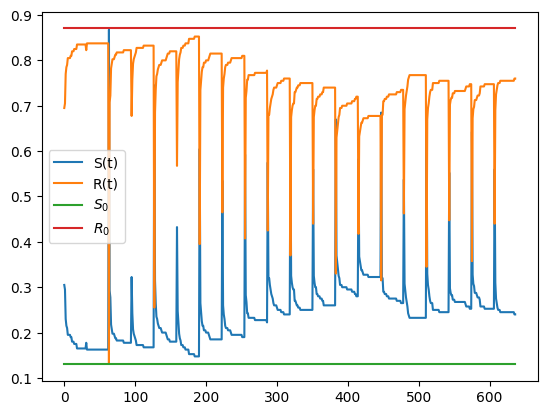

In [ ]:
n = 400       # numb of dancers
grid = 20     # lenght of side of square grid

ratio = 1.2    # ratio of n_l/n_f    ratio = a means n_f = a  n_l
mu = 5       # mean skill distribution  

nu = 5      # expected rest time

eta = 0.8            # distance and skill match importance
sigma = 0.2          


OffGrid = 0.5      # matching radius

V = 0.3        # walking speed
Delta = 0.2      # time step
Party=Dancers(n, grid , ratio, mu , nu , eta , sigma, V , Delta , OffGrid)

duration = 60
song_len = 3
S_t, R_t , lam_t = Party.Party_starts( duration , song_len , Showplots = None , Saveframes = None )

plt.plot(S_t /n, label = "S(t)")
plt.plot(R_t/n , label = "R(t)")

print( np.average(lam_t) )
lam = np.average(lam_t)

a = lam * ( 2* nu + 1)
S_0 =  (-1+np.sqrt(1+4*a)) / (2*a)
R_0 = 2*lam*nu* (S_0**2) + lam*(S_0**2)

plt.plot( S_0 + S_t*0, label="$S_0$")
plt.plot( R_0 + R_t*0, label = "$R_0$")
plt.legend()
plt.show()

# Avoidance Model

Change the values of the parameters here to see different simulations.

If Showplots is given a not None value, individual frames of the simulation at each time step will be shown on the terminal

If Saveframes is given a not None value, the frames will be saved locally and a video will be generated as well showing the evolution over time.

In [49]:
class Dancers_Avoidance:
    def __init__(self, n , grid , ratio , mu , nu , eta ,sigma, kappa , V , Delta , OffGrid = 0.5  ):
        """ Initiating the dance floor
        First we initiate the fixed properties given by the input parameters and then we 
        initiate properties that may change at some time step: position and rest state.

        Offgrid takesthe role of match radius. Hence a match is made if two dancers are 
        within 'OffGrid' distance from eachother.

        Skill levels are assigned according to a Gaussian distribution with mean mu and standard 
        deviation 1. Initial positions are chosen randomly from coordinates on the edges of the grid.

        Furthermore, dancers can have 3 different states: resting, dancing, and searching.
        When resting, the dancers are removed from the dance floor and do not interact with other
        dancers. They are assigned state -1 and a rest value that follows a Poisson distribution 
        with mean nu.
        At each time step, the dancers regain some energy: their rest value increases by 1.
        Once a song ends, dancers that are rested (represented by a 0 rest value) will join 
        the dance floor once again and enter the searching state. 
        While they are searching, their rest state will continue increasing until they find a 
        match and enter the 'Dancing' state. In this state, the dancers are place towards the center
        of the dance floor. 
        At the end of the song they will then enter the resting state.
        """
        #  ======= Fixed Properties =======
        self.Delta = Delta   # Time step
        self.n = n           # Numb of dancers
        self.grid = grid     # Lenght of square grid

        # Assign roles to dancers according to ratio
        self.role = - np.ones(self.n , dtype = int ) 
        self.ratio = ratio
        n_f = int( self.n / ( ratio + 1) ) 
        self.role[:n_f]*=-1

        self.rng = np.random.default_rng()

        # Assign skill levels    
        self.mu = mu         
        self.skill = np.clip( self.rng.normal(mu, 1 , self.n) , 0 , None )

        self.nu = nu / self.Delta       # Resting rate after dancing
        self.eta = eta      # Distance bias in partner search
        self.sigma = sigma  # Skill bias in partner search

        self.kappa = kappa    # avoidance bias

        self.OffGrid = OffGrid     # Match radius for off lattice

        self.radius = self.grid * 0.75 / 2   # radius of dancing area, must be between 0 and 1
        self.center = self.grid / 2   # center of dancing area
        
        self.V = V * self.Delta   # Speed parameter

        #  ======= Mutable Properties =======

        # Generate the edge coordinates of the grid for the OffGrid and OnGrid case
        axis1 = self.rng.random(self.grid + 1) * (self.grid)
        axis2 = np.zeros(self.grid +1 )
        axis3 = (self.grid) * np.ones(self.grid + 1)
        
        edges1 = np.column_stack((axis1.ravel(), axis2.ravel()))
        edges2 = np.column_stack((axis1.ravel(), axis3.ravel()))
        edges3 = np.column_stack((axis2.ravel(), axis1.ravel()))
        edges4 = np.column_stack((axis3.ravel(), axis1.ravel()))
        
        Edges = np.concatenate(( edges1, edges2, edges3, edges4 ))
        self.Edges = np.unique( Edges , axis = 1 )

        self.position = self.rng.choice(self.Edges, self.n, replace=True)   # Assign initial positions of the dancers  

        self.rest = np.zeros(self.n)  # Assign initial rest states

        self.state = np.ones(self.n) # Assign initial state, all dancers are initially searching, denoted q in the report
        self.S = self.n      # Searching population
        self.R = 0           # Resting population
        self.D = 0           # Dancing population
        self.lam = 0         # Matches over time




    def Grid(self , t , Showplots = None , Saveframes = None):
        """Function to visualize the movement of the dancers at each time step
        We plot the dancers on a 2x2 grid. We mark the followers '1' as circles and leaders '-1' as three pointed stars.
        We represent the skill of each dancer by the color of their marker. A colorbar is provided with each plot. 
        We also plot the dancing area by a circle place in the grid. 

        The parameter t is used for the title of the plot. If Showplots is given a value, the the plot will be shown on 
        the terminal. Otherwise if Saveframes is given a value, then the frames are save on a local file.
        """
        # Define grid
        plt.figure(figsize=(6.08, 6.08))
        plt.grid(True , alpha =0.75)
        plt.xlim(-1, self.grid +1)
        plt.ylim(-1, self.grid+1 )
        plt.gca().set_aspect('equal')

        role_markers = {1: '.', -1: '1'}  # Assign markers 

        # Create the colorbar with fixed ticks
        maxskill = int(np.ceil(np.max(self.skill)))
        minskill = int(np.floor(np.min(self.skill)))
        cmap_base = plt.get_cmap('nipy_spectral', maxskill )
        cmap = ListedColormap([cmap_base(i) for i in range( minskill -1 , maxskill ) ])
        norm = Normalize( vmin= minskill - 0.5 , vmax=maxskill + 0.5)

        # Plot the positions for each role with the assigned markers and colors
        for r in [-1 , 1]:
            idx = np.where(self.role == r)[0]
            scatter = plt.scatter(
                self.position[idx, 0], self.position[idx, 1],
                marker=role_markers[r],
                c=self.skill[idx],
                cmap=cmap,
                norm=norm,
                s=1000/self.grid,
                label=f'Role: {r}'
            )

        # Place the colorbar
        cbar = plt.colorbar(scatter, ticks=np.arange( minskill -1, maxskill + 1))
        cbar.set_label('Skill Level')

        plt.legend(loc='upper right' , fontsize = 'xx-small' , markerscale = 0.5)

        plt.title(f"Grid at time t={t}")

        # Plot the borders of the dance floor
        plt.plot(
                [-0.5, -0.5, self.grid + 0.5, self.grid + 0.5, -0.5],  # x-coords
                [-0.5, self.grid + 0.5, self.grid + 0.5, -0.5, -0.5],  # y-coords
                color='black', linewidth=2)
        
        # Add a circle in the center of the grid to represent the dancefloor
        circle = Circle((self.center, self.center), self.radius,fill=False, alpha=0.3, zorder=1)
        plt.gca().add_patch(circle)
        
        # Save or show the plots
        if Saveframes is not None: 
            # Create directory if needed
            os.makedirs(f'kappa={self.kappa},Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}', exist_ok=True)
            filename = f'kappa={self.kappa},Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/frame_{t:06.2f}.png'
            plt.savefig(filename)
        if Showplots is not None:
            plt.show(scatter)
        plt.close()



    def Movement(self , r): 
        """ Movement function 
        At every time step, the dancers move according to the the criteria described 
        in the report. We only consider dancers that are not resting, here referred to as 'valid dancers'.

        We compute matrix A with 

            A_{ij}= ( ( \frac{1-sign(r_i r_j)}{2} ) e^{- eta  ||x_i - x_j|| } e^{- sigma |s_i - s_j| } )^( q_i q_j )  ( -e^{ - \kappa ||x_i-x_j|| })^( 1 - q_i q_j) q_i

        with r_i , x_i and s_i being the role, the position and the skill level of dancer i respectively.

        For the Offgrid model, we compute the force vector to determine the motion of the dancers. The new
        position is determined by 

            x_i(t+Dt) = x_i(t) + DtF_i

        On the boundary we enforce solid wall boundaries. If a dancer would move across a wall, the movement is blocked and 
        dancer does not move.

        To avoid dancers skipping over each other, we split the movement of the dancers. Only dancers with role r given in 
        the input will move. 
        """

        valid_mask = (~np.isnan(self.position).any(axis=1) ) # Only move dancers in the searching or dancing state (valid dancers)
        valid_indices = np.where(valid_mask)[0] # Get indices of valid to place the new positions in the full array later

        # Extract properties of valid dancers
        clean_position = self.position[valid_mask]
        clean_role     = self.role[valid_mask]  
        clean_skill    = self.skill[valid_mask]
        clean_state    = self.state[valid_mask]

        # Compute A
        role_match = ( 1-np.sign(  np.outer(clean_role , clean_role ) )   ) * 0.5   # Role bias

        dist= np.linalg.norm( clean_position[:, np.newaxis, :] - clean_position[np.newaxis, :, :], axis=2)  # Distance bias
        dist_match = np.exp(- self.eta * dist)

        skilly = np.abs(clean_skill[:, None] - clean_skill[None, :])  # Skill bias
        skill_match= np.exp(- self.sigma * skilly )

        avoidance_force = - np.exp(-  dist * self.kappa )  # avoidance force

        power = np.outer(clean_state , clean_state)     # state checker

        A = ( role_match * dist_match * skill_match )**power * ( avoidance_force**(1-power) ) * clean_state[:, np.newaxis]

        delta = clean_position[np.newaxis, :, :] - clean_position[:, np.newaxis, :]  # delta[i, j] = position[i] - position[j]

        # For the Offgrid model, compute the force vector F
        dist = np.linalg.norm( delta , axis = 2 , keepdims=True )
        dist =  np.where(dist == 0 , 1 , dist )
        X  = delta / dist
        F = self.V * np.einsum('ij, ijk -> ik', A, X)
        clean_position += F

        # Solid wall boundaries
        # clean_position = clean_position % self.grid   # periodic boundaries can be implemented
        clean_position = np.clip( clean_position , 0, self.grid )   # solid wall boundaries

        # Move only one role at a time
        role_mask = clean_role == r
        dancer_indices = valid_indices[role_mask]

        # Place the new positions in the position array
        self.position[dancer_indices] = clean_position[role_mask]





    def Match(self):
        """ Match function 
        Once dancers fit the criteria to dance together, they are paired up and removed from the grid. 

        For the OffGrid model, we consider dancers that are 'OffGrid' distance away from each other. 

        We then extract the pairs (i,j) that are close enough and match up dancers, making sure they are role 
        compatible and that they have not been matched with someone else already.

        Dancers that have been matched are then moved away from the grid at position 'nan' and enter the resting
        state. 
        """



        # Initiate array that contains the dancers that will dance
        dancing = np.full(self.n, fill_value= False , dtype=bool)

        # Compute distances
        delta = self.position[np.newaxis, :, :] - self.position[:, np.newaxis, :]
        delta_matrix = np.linalg.norm(delta, axis=2)

        # Proximity match
        near_mask = (delta_matrix <= self.OffGrid) & (self.state == 1) # Only up to OffGrid and if they are in searching state

        # Extract pairs (i, j) that are close enough
        pairs = np.transpose(np.nonzero(np.triu(near_mask, k=1)))

        # Match up the dancers
        taken = np.zeros( self.n , dtype=bool)
        for i ,j in pairs:
            if not taken[i] and not taken[j] and self.role[i] * self.role[j] < 0:
                dancing[i] = dancing[j] = True
                taken[i] = taken[j] = True

                # Place pair close together on the dancefloor ---
                r = self.radius * np.sqrt(self.rng.random())   # random radius
                theta = 2 * np.pi * self.rng.random()          # random angle
                center_x = self.center + r * np.cos(theta)
                center_y = self.center + r * np.sin(theta)

                # Slight offset so they don't overlap
                offset = self.rng.normal(0, 0.2, size=(2, 2)) 
                self.position[i] = [center_x, center_y] + offset[0]
                self.position[j] = [center_x, center_y] + offset[1]

                # Update states immediately
                self.state[i] = 0
                self.state[j] = 0

                self.S -= 2
                self.D += 2
                self.lam += 2

    def Party_starts(self, duration , song_duration , Showplots = None , Saveframes=True):
        """ Party starts function
        Here we simulate a salsa party, using the various functions we have created.

        The party starts in the initialization of the dancers. We match any dancers that are close
        enough to each other in their initial position at t=0.  
        Then at each time step, we move the leaders and check if any matches can be made. We repeat
        the same process for the followers within the same time step. We also increase the rest value
        of all dancers.
        Whenever we reach the end of a song, determined by song_len, we check which resting dancers are
        done resting and can be placed back into the grid. We place them randomly along the border of the 
        grid and check if they can lead to any new matches. We also check which dancing dancers should go rest.
        The party ends at time song_duration.

        After every movement or match, we use the Grid function to plot and/or save the frames locally.
        For storing purposes, the leaders move at time t=t', followers move at time t=t'+0.5 and dancers
        are reintroduced to the grid after resting at time t=t'+0.75.
        Furthemore, in case the frames are saved, the function also produces a video of the movement of the dancers.     
        """
        # Initialize populations arrays
        S_t = np.array([])
        R_t = np.array([])
        D_t = np.array([])
        lam_t = np.array([])

        # Check for matches
        self.Match()
        # Recording the change in population
        S_t = np.append(S_t , self.S) 
        R_t = np.append(R_t , self.R)
        D_t = np.append(D_t , self.D)
        lam_t = np.append(lam_t , self.lam)
        self.lam = 0

        if Showplots is not None or Saveframes is not None:
            self.Grid(0 ,Showplots = Showplots , Saveframes = Saveframes)

        for t in range(1, int(duration/self.Delta) ):   # The song starts, at each time step dancers move and match

            # === 1. Move leaders only ===
            self.Movement(-1)
            self.Match()
            # Recording the change in population
            S_t = np.append(S_t , self.S) 
            R_t = np.append(R_t , self.R)
            D_t = np.append(D_t , self.D)
            lam_t = np.append(lam_t , self.lam)
            self.lam = 0

            if Showplots is not None or Saveframes is not None:
                self.Grid(t , Showplots = Showplots , Saveframes = Saveframes)

            # === 2. Move followers only ===
            self.Movement(1)
            self.Match()
            # Recording the change in population
            S_t = np.append(S_t , self.S) 
            R_t = np.append(R_t , self.R)
            D_t = np.append(D_t , self.D)
            lam_t = np.append(lam_t , self.lam)
            self.lam = 0
            
            if Showplots is not None or Saveframes is not None:
                self.Grid(t+0.5, Showplots = Showplots, Saveframes = Saveframes)

            self.rest += 1 
        
            if t % int(song_duration/ self.Delta) == 0:
                # Check which dancing dancers should go rest                
                dancing_mask = (self.state == 0)
                self.position[dancing_mask] = np.array([ np.nan , np.nan])
                self.rest[dancing_mask] = -self.rng.poisson( self.nu , dancing_mask.sum() )    
                self.state[dancing_mask] = - np.ones( dancing_mask.sum() ) 
                self.D -= len(self.position[dancing_mask])  
                self.R += len(self.position[dancing_mask])  

                # Check which resting dancers should come back into the grid
                rested =  (self.rest >= 0) & (self.state == -1)
                self.position[ rested ] = self.rng.choice(self.Edges, rested.sum() , replace=True)  
                self.state[ rested ] = np.ones( rested.sum() ) 
                self.R -= len(self.position[rested])
                self.S += len(self.position[rested])  
                # Recording the change in population
                S_t = np.append(S_t , self.S) 
                R_t = np.append(R_t , self.R)
                D_t = np.append(D_t , self.D)
                lam_t = np.append(lam_t , self.lam)
                self.lam = 0

                if Showplots is not None or Saveframes is not None:
                    self.Grid(t+0.65, Showplots = Showplots, Saveframes = Saveframes)

                self.Match()
                # Recording the change in population
                S_t = np.append(S_t , self.S) 
                R_t = np.append(R_t , self.R)
                D_t = np.append(D_t , self.D)
                lam_t = np.append(lam_t , self.lam)
                self.lam = 0

                if Showplots is not None or Saveframes is not None:
                    self.Grid(t+0.85, Showplots = Showplots, Saveframes = Saveframes)
        
        if Showplots is not None or Saveframes is not None:
            self.Grid(t+1, Showplots = Showplots, Saveframes = Saveframes)        
            
        # Save a video of the movement
        if Saveframes is not None:
            filenames = sorted(glob.glob(f'kappa={self.kappa},Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/frame_*.png'))
            with imageio.get_writer(f'kappa={self.kappa},Grid{self.OffGrid}frames_param_n={self.n},g={self.grid},ratio={self.ratio},mu={self.mu},nu={self.nu},eta={self.eta},sigma={self.sigma}/dance_video_{duration}.mp4', fps=2) as writer:
                for filename in filenames:
                    image = imageio.v2.imread(filename)
                    writer.append_data(image)
            print(f"Video saved to 'dance_video.mp4'")
        return S_t , R_t , D_t , lam_t


4.5133740028155795


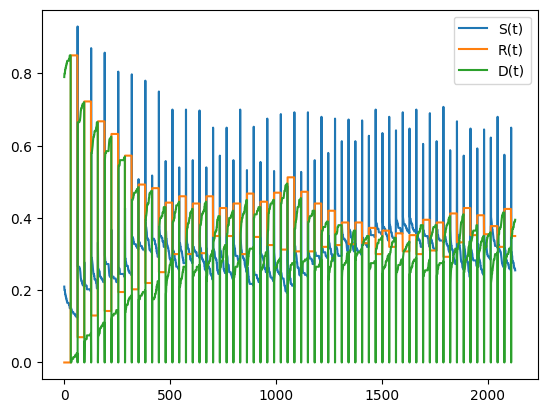

In [60]:
n = 400  
grid = 20

ratio = 1.2    # ratio of n_l/n_f    ratio = a means n_f = a  n_l
mu = 5       # skill expectation distribution  

nu = 2      # resting rate

eta = 0.8            # distance and skill match importance
sigma = 0.2         


OffGrid = 0.5    # match radius

kappa = 0.8      # avoidance parameter
V = 0.3          # walking speed
Delta = 0.2      # time step
Party=Dancers_Avoidance(n, grid , ratio, mu , nu , eta , sigma , kappa, V , Delta , OffGrid)

duration = 200  # party duration
song_len = 3   # song duration

S_t, R_t , D_t , lam_t =  Party.Party_starts( duration , song_len , Showplots = None , Saveframes = None )

plt.plot(S_t /n, label = "S(t)")
plt.plot(R_t/n , label = "R(t)")
plt.plot(D_t /n, label = "D(t)")

print( np.average(lam_t) )
lam = np.average(lam_t)

a = lam * ( 2* nu + 1)
S_0 =  (-1+np.sqrt(1+4*a)) / (2*a)
R_0 = 2*lam*nu* (S_0**2) 
D_0 = lam*(S_0**2)

# plt.plot( S_0 + S_t*0, label="$S_0$")
# plt.plot( R_0 + R_t*0, label = "$R_0$")
# plt.plot( D_0 + D_t*0, label = "$D_0$")
plt.legend()
plt.show()

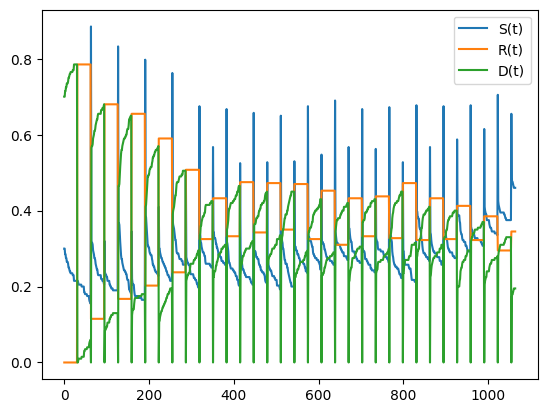

In [58]:
plt.plot(S_t /n, label = "S(t)")
plt.plot(R_t/n , label = "R(t)")
plt.plot(D_t /n, label = "D(t)")

plt.legend()
plt.show()